# 01 — Data Exploration

First look at the 5G network dataset: structure, quality, 5G-specific features, and basic patterns.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data_loader import load_raw

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
# Load the raw 5G dataset
df = load_raw()
print(f'Shape: {df.shape}')
df.head(10)

Shape: (188711, 28)


,Timestamp,Longitude,Latitude,Speed,Operatorname,CellID,NetworkMode,RSRP,RSRQ,SNR,...,PINGSTDEV,PINGLOSS,CELLHEX,NODEHEX,LACHEX,RAWCELLID,NRxRSRP,NRxRSRQ,Application,Mobility
0,2019-11-20 16:55:16,-8.499476,51.893446,0,B,3,LTE,-79,-12.0,10.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
1,2019-11-20 16:55:16,-8.499567,51.893413,0,B,3,LTE,-79,-12.0,10.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
2,2019-11-20 16:55:16,-8.499567,51.893413,0,B,3,LTE,-79,-12.0,7.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
3,2019-11-20 16:55:17,-8.499567,51.893413,0,B,3,LTE,-79,-12.0,7.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
4,2019-11-20 16:55:18,-8.499567,51.893413,0,B,3,LTE,-78,-12.0,10.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
5,2019-11-20 16:55:19,-8.499567,51.893413,0,B,3,LTE,-78,-12.0,10.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
6,2019-11-20 16:55:20,-8.499567,51.893413,0,B,3,LTE,-78,-12.0,11.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
7,2019-11-20 16:55:21,-8.499567,51.893413,0,B,3,LTE,-78,-12.0,11.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
8,2019-11-20 16:55:22,-8.499567,51.893413,0,B,3,LTE,-77,-12.0,10.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving
9,2019-11-20 16:55:23,-8.499567,51.893413,0,B,3,LTE,-77,-12.0,10.0,...,NaN,NaN,3,76C6C,9CBA,124546051,NaN,NaN,Netflix,Driving


In [3]:
# Column info & dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188711 entries, 0 to 188710
Data columns (total 28 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Timestamp     188711 non-null  datetime64[us]
 1   Longitude     188711 non-null  float64       
 2   Latitude      188711 non-null  float64       
 3   Speed         188711 non-null  int64         
 4   Operatorname  188711 non-null  str           
 5   CellID        188711 non-null  int64         
 6   NetworkMode   188711 non-null  str           
 7   RSRP          188711 non-null  int64         
 8   RSRQ          185077 non-null  float64       
 9   SNR           171615 non-null  float64       
 10  CQI           171614 non-null  float64       
 11  RSSI          135138 non-null  float64       
 12  DL_bitrate    188711 non-null  int64         
 13  UL_bitrate    188711 non-null  int64         
 14  State         188711 non-null  str           
 15  PINGAVG       3208 non-null 

In [4]:
# Missing values
missing = df.isnull().sum()
missing[missing > 0]

RSRQ           3634
SNR           17096
CQI           17097
RSSI          53573
PINGAVG      185503
PINGMIN      185503
PINGMAX      185503
PINGSTDEV    185503
PINGLOSS     185439
NODEHEX         176
NRxRSRP       34498
NRxRSRQ       37242
dtype: int64

In [ ]:
# Time range
ts_col = config.TIMESTAMP_COLUMN
print(f'From: {df[ts_col].min()}  →  To: {df[ts_col].max()}')
print(f'Granularity: ~{df[ts_col].diff().median()}')

NetworkMode
5G       136403
LTE       35212
HSPA+     15880
UMTS        492
HSUPA       470
HSDPA       163
GPRS         78
EDGE         13
Name: count, dtype: int64


Text(0.5, 1.0, 'Network Mode Distribution (5G / LTE / HSPA+)')

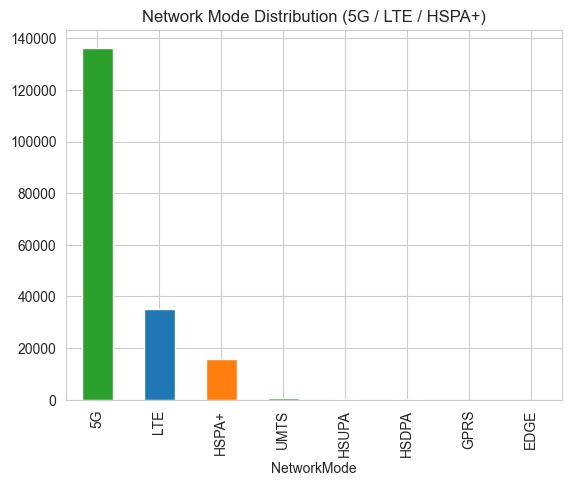

In [6]:
# 5G-specific: Network Mode distribution
print(df['NetworkMode'].value_counts())
ax = df['NetworkMode'].value_counts().plot(kind='bar', color=['#2ca02c','#1f77b4','#ff7f0e'])
ax.set_title('Network Mode Distribution (5G / LTE / HSPA+)')

Application
Netflix         72832
Amazon_Prime    72671
Download        43208
Name: count, dtype: int64

Text(0.5, 1.0, 'Application Type Distribution')

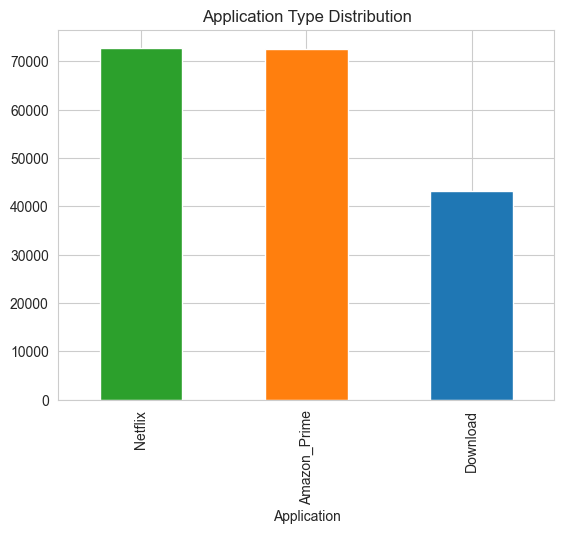

In [7]:
# 5G-specific: Application distribution
print(df['Application'].value_counts())
ax = df['Application'].value_counts().plot(kind='bar', color=['#2ca02c','#ff7f0e','#1f77b4'])
ax.set_title('Application Type Distribution')

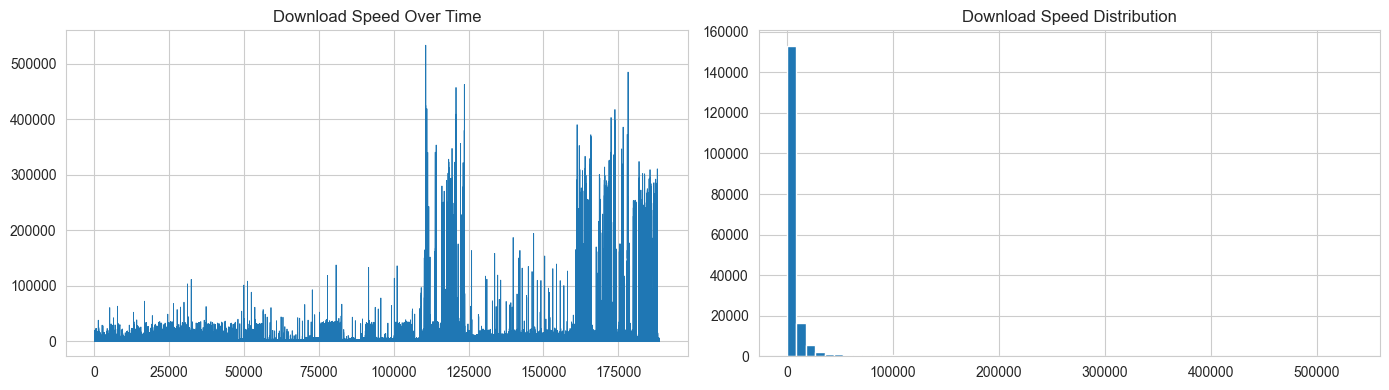

In [8]:
# Throughput distribution
target = config.TARGET_COLUMN
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[target].plot(ax=axes[0], linewidth=0.6)
axes[0].set_title('Download Speed Over Time')
df[target].hist(bins=60, ax=axes[1], edgecolor='white')
axes[1].set_title('Download Speed Distribution')
plt.tight_layout()

Text(0.5, 1.0, 'RSRP (Signal Strength) vs Throughput')

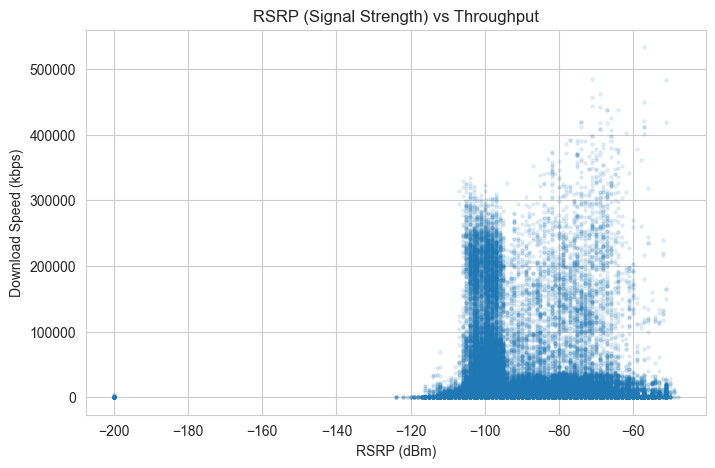

In [9]:
# RSRP vs Download Speed
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['RSRP'], df[target], alpha=0.1, s=5)
ax.set_xlabel('RSRP (dBm)')
ax.set_ylabel('Download Speed (kbps)')
ax.set_title('RSRP (Signal Strength) vs Throughput')

In [10]:
# Quick stats
df[target].describe()

count    188711.000000
mean      10758.245603
std       36746.787199
min           0.000000
25%           0.000000
50%           2.000000
75%        4480.000000
max      532905.000000
Name: DL_bitrate, dtype: float64

## Notes
- 188,711 records from real 5G drive tests (uccmisl/5Gdataset, published at ACM MMSys 2020)
- 1-second granularity, collected via G-NetTrack Pro on Irish mobile operator
- Network Modes: 5G, LTE, HSPA+ (real multi-RAT deployment)
- Applications: Netflix, Amazon Prime, File Download
- Mobility: Driving vs Static scenarios
- Rich RF features: RSRP, RSRQ, SNR, CQI, RSSI
- Target: DL_bitrate (mean ~10.8 Mbps, max ~533 Mbps)